In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('bitcoin.csv')

In [3]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2713 entries, 0 to 2712
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2713 non-null   object 
 1   Open       2713 non-null   float64
 2   High       2713 non-null   float64
 3   Low        2713 non-null   float64
 4   Close      2713 non-null   float64
 5   Adj Close  2713 non-null   float64
 6   Volume     2713 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 148.5+ KB


In [5]:
df.shape

(2713, 7)

In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2713.000000,2713.000000,2713.000000,2713.000000,2713.000000,2.713000e+03
mean,11311.041069,11614.292482,10975.555057,11323.914637,11323.914637,1.470462e+10
std,16106.428891,16537.390649,15608.572560,16110.365010,16110.365010,2.001627e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,606.396973,609.260986,604.109985,606.718994,606.718994,7.991080e+07
50%,6301.569824,6434.617676,6214.220215,6317.609863,6317.609863,5.098183e+09
75%,10452.399414,10762.644531,10202.387695,10462.259766,10462.259766,2.456992e+10
max,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11


In [7]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [8]:
if 'Adj Close' in df.columns:
    df.drop('Adj Close', axis=1, inplace=True)

df.head()

,Date,Open,High,Low,Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100


In [9]:
X = df[['Open', 'High', 'Low', 'Volume']]

y = df['Close']

In [10]:
X.head()

,Open,High,Low,Volume
0,465.864014,468.174011,452.421997,21056800
1,456.859985,456.859985,413.104004,34483200
2,424.102997,427.834991,384.532013,37919700
3,394.673004,423.295990,389.882996,36863600
4,408.084991,412.425995,393.181000,26580100


In [11]:
y.head()

0    457.334015
1    424.440002
2    394.795990
3    408.903992
4    398.821014
Name: Close, dtype: float64

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
print(X_train.shape)
print(X_test.shape)

(2170, 4)
(543, 4)


In [14]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [15]:
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [16]:
y_pred = model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE =", mae)

MAE = 193.06304218914312


In [18]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print("RMSE =", rmse)

RMSE = 441.03662889736995


In [19]:
r2 = r2_score(y_test, y_pred)

print("R2 Score =", r2)

R2 Score = 0.9992919168715131


In [20]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,386.549011,389.919347
1,4017.268555,4170.053640
2,7448.307617,7511.834138
3,1133.250000,1156.519733
4,43099.699219,42408.585020
5,243.593994,242.131594
6,386.354004,413.304631
7,17706.900391,17605.949356
8,55907.199219,58817.031953
9,41821.261719,41066.512656


In [21]:
new_data = pd.DataFrame({
    'Open': [108000],
    'High': [109500],
    'Low': [107500],
    'Volume': [45000000000]
})

prediction = model.predict(new_data)

print("Predicted Bitcoin Closing Price = $", prediction[0])

Predicted Bitcoin Closing Price = $ 66658.49890635493


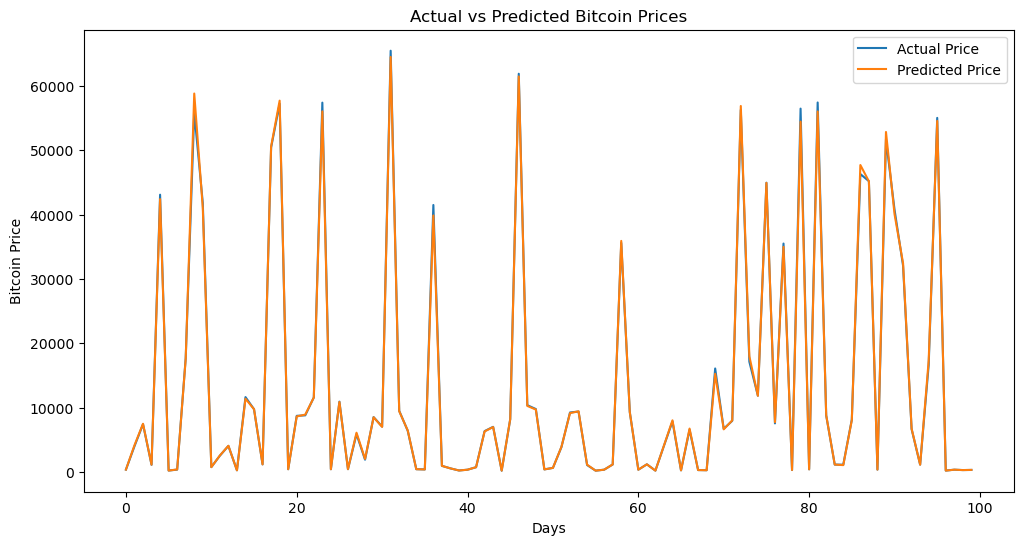

In [22]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual Price')

plt.plot(y_pred[:100], label='Predicted Price')

plt.xlabel("Days")

plt.ylabel("Bitcoin Price")

plt.title("Actual vs Predicted Bitcoin Prices")

plt.legend()

plt.show()

In [23]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison = comparison.reset_index(drop=True)

comparison.head(20)

,Actual,Predicted
0,386.549011,389.919347
1,4017.268555,4170.053640
2,7448.307617,7511.834138
3,1133.250000,1156.519733
4,43099.699219,42408.585020
5,243.593994,242.131594
6,386.354004,413.304631
7,17706.900391,17605.949356
8,55907.199219,58817.031953
9,41821.261719,41066.512656


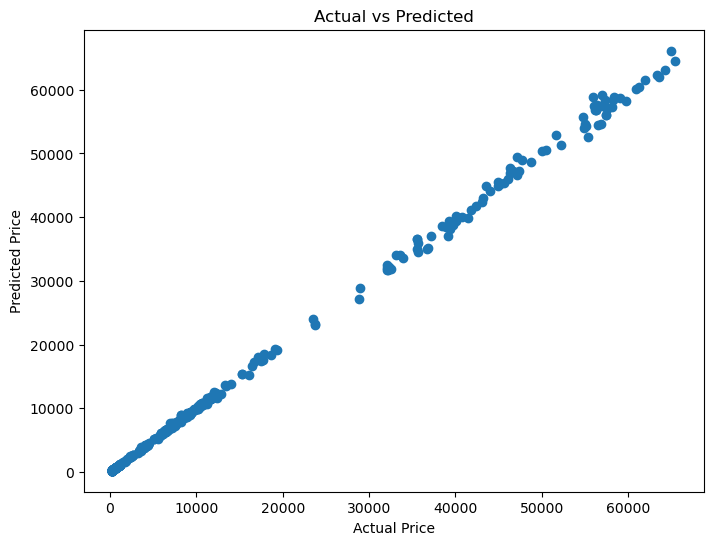

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [25]:
new_data = pd.DataFrame({
    'Open':[108000],
    'High':[109500],
    'Low':[107500],
    'Volume':[45000000000]
})

prediction = model.predict(new_data)

print("Predicted Bitcoin Closing Price = $", prediction[0])

Predicted Bitcoin Closing Price = $ 66658.49890635493


In [26]:
open_price = float(input("Enter Open Price: "))
high_price = float(input("Enter High Price: "))
low_price = float(input("Enter Low Price: "))
volume = float(input("Enter Volume: "))

new_data = pd.DataFrame({
    'Open':[open_price],
    'High':[high_price],
    'Low':[low_price],
    'Volume':[volume]
})

prediction = model.predict(new_data)

print("\nPredicted Bitcoin Closing Price = $", round(prediction[0],2))

Enter Open Price:  522
Enter High Price:  700
Enter Low Price:  300
Enter Volume:  356825



Predicted Bitcoin Closing Price = $ 566.08


In [27]:
import joblib

joblib.dump(model, 'bitcoin_model.pkl')

print("Model Saved Successfully!")

Model Saved Successfully!


In [30]:
import os

print(os.path.exists("bitcoin_model.pkl"))

True


In [31]:
!pip install streamlit

In [32]:
!streamlit --version

Streamlit, version 1.37.1


In [ ]:
app_code = '''
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("bitcoin_model.pkl")

st.title("Bitcoin Price Prediction")

st.write("Enter Bitcoin Market Details")

open_price = st.number_input("Open Price", value=100.0)
high_price = st.number_input("High Price", value=110.0)
low_price = st.number_input("Low Price", value=90.0)
volume = st.number_input("Volume", value=1000.0)

if st.button("Predict Price"):

    data = pd.DataFrame({
        "Open":[open_price],
        "High":[high_price],
        "Low":[low_price],
        "Volume":[volume]
    })

    prediction = model.predict(data)

    st.success(
        f"Predicted Bitcoin Closing Price = ${prediction[0]:.2f}"
   ''' )


with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully!")

In [34]:
import os

print(os.path.exists("app.py"))

True


In [ ]:
!streamlit run app.py